# Análisis exploratorio de datos (EDA)

**Autora:** Leydy Osorio Vargas  
**Fecha:** 2026-09-08

## Descripción

Este notebook caracteriza el conjunto de datos de enfermedad cardiaca después de la corrección estructural realizada en la Tarea 2. Se estudian el esquema, la completitud, los duplicados, las distribuciones, los valores atípicos y las asociaciones univariables, bivariables y multivariables. También se proponen reglas de validación, transformaciones para Feature Engineering y una heurística transparente que pueda utilizarse como *baseline*.

El análisis es exploratorio: las asociaciones observadas no demuestran causalidad y la heurística no constituye una regla clínica ni reemplaza la valoración de profesionales de la salud.


## Alcance y decisiones analíticas

- La fuente de esta etapa es `data/02_intermediate/corazon_type_fixed.parquet`.
- El dataset persistido no se modifica en este notebook.
- Como existen muchas filas exactamente duplicadas y no hay un identificador de paciente, se presentan primero los resultados del dataset completo y luego se utiliza una vista temporal sin duplicados para evitar que las repeticiones dominen las estadísticas y las asociaciones.
- La eliminación definitiva de duplicados, la imputación y el *encoding* pertenecen a Feature Engineering.
- Solo se muestran resultados agregados; no se publican registros individuales de pacientes.


## 📚 Importar librerías


In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
COLOR_NEGATIVE = "#4C78A8"
COLOR_POSITIVE = "#E45756"
COLOR_NEUTRAL = "#72B7B2"
MIN_LEVELS = 2

## 💾 Cargar el dataset intermedio


In [2]:
PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = next(
        parent
        for parent in PROJECT_DIR.parents
        if (parent / "data").is_dir() and (parent / "pyproject.toml").exists()
    )

INTERMEDIATE_FILE = PROJECT_DIR / "data" / "02_intermediate" / "corazon_type_fixed.parquet"

if not INTERMEDIATE_FILE.exists():
    raise FileNotFoundError(
        "No se encontró el Parquet intermedio. Ejecute primero el notebook de la "
        "Tarea 2: notebooks/2-exploration/02.Exploracion-ljov-2026-09-06.ipynb"
    )

heart_df = pd.read_parquet(INTERMEDIATE_FILE)

print(f"Archivo cargado: {INTERMEDIATE_FILE.relative_to(PROJECT_DIR)}")
print(f"Dimensiones: {heart_df.shape[0]:,} filas y {heart_df.shape[1]} columnas")

Archivo cargado: data/02_intermediate/corazon_type_fixed.parquet
Dimensiones: 3,030 filas y 14 columnas


## 📊 Panorama general y esquema


In [3]:
dataset_summary = pd.DataFrame(
    {
        "value": [
            heart_df.shape[0],
            heart_df.shape[1],
            heart_df.isna().sum().sum(),
            heart_df.duplicated().sum(),
            heart_df.drop_duplicates().shape[0],
        ]
    },
    index=[
        "rows",
        "columns",
        "missing_cells",
        "exact_duplicate_rows",
        "unique_rows",
    ],
)

dataset_summary

,value
rows,3030
columns,14
missing_cells,1680
exact_duplicate_rows,2462
unique_rows,568


In [4]:
variable_schema = pd.DataFrame(
    [
        ("age", "numérica discreta", "años", "predictora", "Edad"),
        ("sex", "categórica nominal", "categoría", "predictora", "Sexo"),
        ("chest_pain", "categórica nominal", "categoría", "predictora", "Tipo de dolor torácico"),
        ("rest_bp", "numérica discreta", "mmHg", "predictora", "Presión arterial en reposo"),
        ("chol", "numérica discreta", "mg/dL", "predictora", "Colesterol sérico"),
        ("fbs", "booleana", ">120 mg/dL", "predictora", "Glucosa en ayunas sobre el umbral"),
        ("rest_ecg", "categórica nominal", "categoría", "predictora", "ECG en reposo"),
        ("max_hr", "numérica discreta", "bpm", "predictora", "Frecuencia cardiaca máxima"),
        ("exang", "booleana", "sí/no", "predictora", "Angina inducida por ejercicio"),
        (
            "old_peak",
            "numérica continua",
            "depresión ST",
            "predictora",
            "Depresión ST inducida por ejercicio",
        ),
        (
            "slope",
            "categórica ordinal codificada",
            "1-3",
            "predictora",
            "Pendiente del segmento ST",
        ),
        ("ca", "numérica discreta acotada", "0-3", "predictora", "Número de vasos principales"),
        ("thal", "categórica nominal", "categoría", "predictora", "Resultado del estudio thal"),
        ("disease", "booleana", "sí/no", "objetivo", "Presencia de enfermedad cardiaca"),
    ],
    columns=["variable", "nature", "unit_or_domain", "role", "meaning"],
).set_index("variable")

variable_schema["dtype"] = heart_df.dtypes.astype(str)
variable_schema["missing_pct_full"] = (heart_df.isna().mean() * 100).round(2)
variable_schema

,nature,unit_or_domain,role,meaning,dtype,missing_pct_full
variable,,,,,,
age,numérica discreta,años,predictora,Edad,Int16,1.06
sex,categórica nominal,categoría,predictora,Sexo,category,2.11
chest_pain,categórica nominal,categoría,predictora,Tipo de dolor torácico,category,2.84
rest_bp,numérica discreta,mmHg,predictora,Presión arterial en reposo,Int16,2.74
chol,numérica discreta,mg/dL,predictora,Colesterol sérico,Int16,2.87
fbs,booleana,>120 mg/dL,predictora,Glucosa en ayunas sobre el umbral,boolean,3.20
rest_ecg,categórica nominal,categoría,predictora,ECG en reposo,category,6.53
max_hr,numérica discreta,bpm,predictora,Frecuencia cardiaca máxima,Int16,5.68
exang,booleana,sí/no,predictora,Angina inducida por ejercicio,boolean,5.05


### Duplicados y unidad de análisis

El dataset contiene **2.462 filas exactamente duplicadas** y solo **568 combinaciones únicas**. Esto significa que el 81,25 % de las filas repite completamente otra observación. La ausencia de un identificador de paciente impide demostrar si todas las repeticiones son errores, pero mantenerlas en el análisis sobreponderaría ciertos perfiles.

Por esta razón se crea `analysis_df` únicamente como vista analítica sin duplicados. El Parquet intermedio permanece intacto y la decisión de eliminación se implementará formalmente en el pipeline de Feature Engineering.


In [5]:
duplicate_columns = [
    (first, second)
    for first, second in combinations(heart_df.columns, 2)
    if heart_df[first].astype("string").equals(heart_df[second].astype("string"))
]

analysis_df = heart_df.drop_duplicates().copy()

duplicate_audit = pd.Series(
    {
        "total_rows": len(heart_df),
        "exact_duplicate_rows": int(heart_df.duplicated().sum()),
        "duplicate_row_percentage": round(heart_df.duplicated().mean() * 100, 2),
        "unique_rows_for_eda": len(analysis_df),
        "exact_duplicate_column_pairs": len(duplicate_columns),
    },
    name="value",
).to_frame()

duplicate_audit

,value
total_rows,3030.00
exact_duplicate_rows,2462.00
duplicate_row_percentage,81.25
unique_rows_for_eda,568.00
exact_duplicate_column_pairs,0.00


## 🔍 Calidad de datos y valores faltantes


In [6]:
missing_comparison = pd.DataFrame(
    {
        "missing_full": heart_df.isna().sum(),
        "missing_pct_full": (heart_df.isna().mean() * 100).round(2),
        "missing_unique": analysis_df.isna().sum(),
        "missing_pct_unique": (analysis_df.isna().mean() * 100).round(2),
    }
).sort_values("missing_pct_unique", ascending=False)

missing_comparison

,missing_full,missing_pct_full,missing_unique,missing_pct_unique
rest_ecg,198,6.53,175,30.81
max_hr,172,5.68,149,26.23
exang,153,5.05,130,22.89
old_peak,152,5.02,129,22.71
slope,152,5.02,129,22.71
ca,163,5.38,106,18.66
thal,130,4.29,92,16.20
disease,111,3.66,88,15.49
fbs,97,3.20,83,14.61
chol,87,2.87,73,12.85


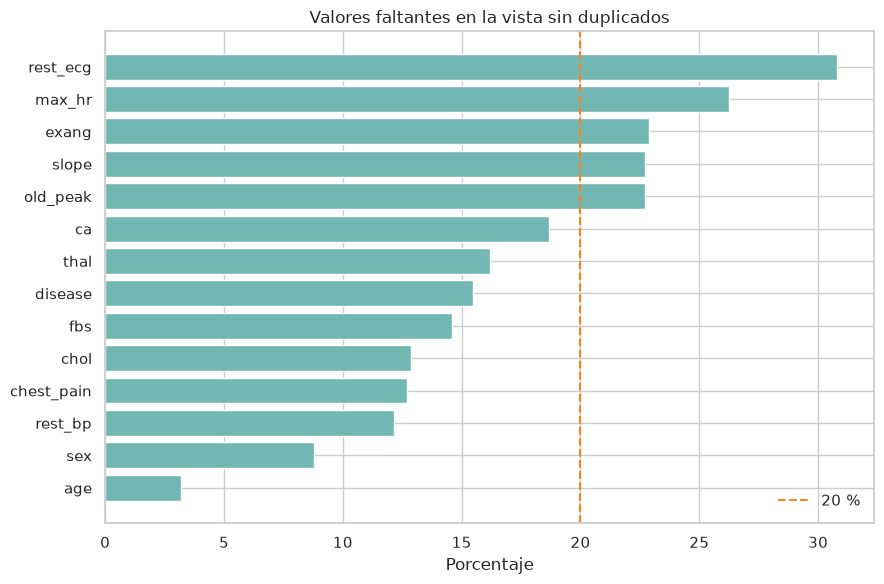

In [7]:
plot_data = missing_comparison.sort_values("missing_pct_unique")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data.index, plot_data["missing_pct_unique"], color=COLOR_NEUTRAL)
ax.axvline(20, color="#F58518", linestyle="--", linewidth=1.5, label="20 %")
ax.set(title="Valores faltantes en la vista sin duplicados", xlabel="Porcentaje", ylabel="")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Después de retirar repeticiones solo para el análisis, los porcentajes de nulos aumentan. `rest_ecg` alcanza 30,81 %, `max_hr` 26,23 % y varias variables de pruebas de esfuerzo superan 20 %. Esto revela que las filas completas estaban más repetidas que las incompletas; por tanto, la duplicación no es uniforme.

Los faltantes no deben imputarse antes de dividir train/test. La estrategia debe formar parte de un pipeline ajustado exclusivamente con train para evitar fuga de información. Además, `disease` tiene 15,49 % de faltantes en la vista única; esas filas no pueden emplearse como ejemplos supervisados mientras no exista una etiqueta confiable.


## 📈 Análisis univariable: variables numéricas


In [8]:
numeric_columns = ["age", "rest_bp", "chol", "max_hr", "old_peak"]

numeric_summary = analysis_df[numeric_columns].describe().T
numeric_summary["missing_pct"] = (analysis_df[numeric_columns].isna().mean() * 100).round(2)
numeric_summary["skewness"] = analysis_df[numeric_columns].skew()
numeric_summary["kurtosis"] = analysis_df[numeric_columns].kurt()

numeric_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness,kurtosis
age,550.0,54.66,9.06,29.0,47.25,56.0,61.0,77.0,3.17,-0.15,-0.58
rest_bp,499.0,131.12,17.27,94.0,120.0,130.0,140.0,200.0,12.15,0.62,0.56
chol,495.0,247.92,53.19,126.0,211.0,243.0,278.0,564.0,12.85,1.45,6.6
max_hr,419.0,149.89,22.06,71.0,138.0,152.0,165.0,202.0,26.23,-0.53,0.02
old_peak,439.0,1.07,1.2,0.0,0.0,0.8,1.8,6.2,22.71,1.28,1.6


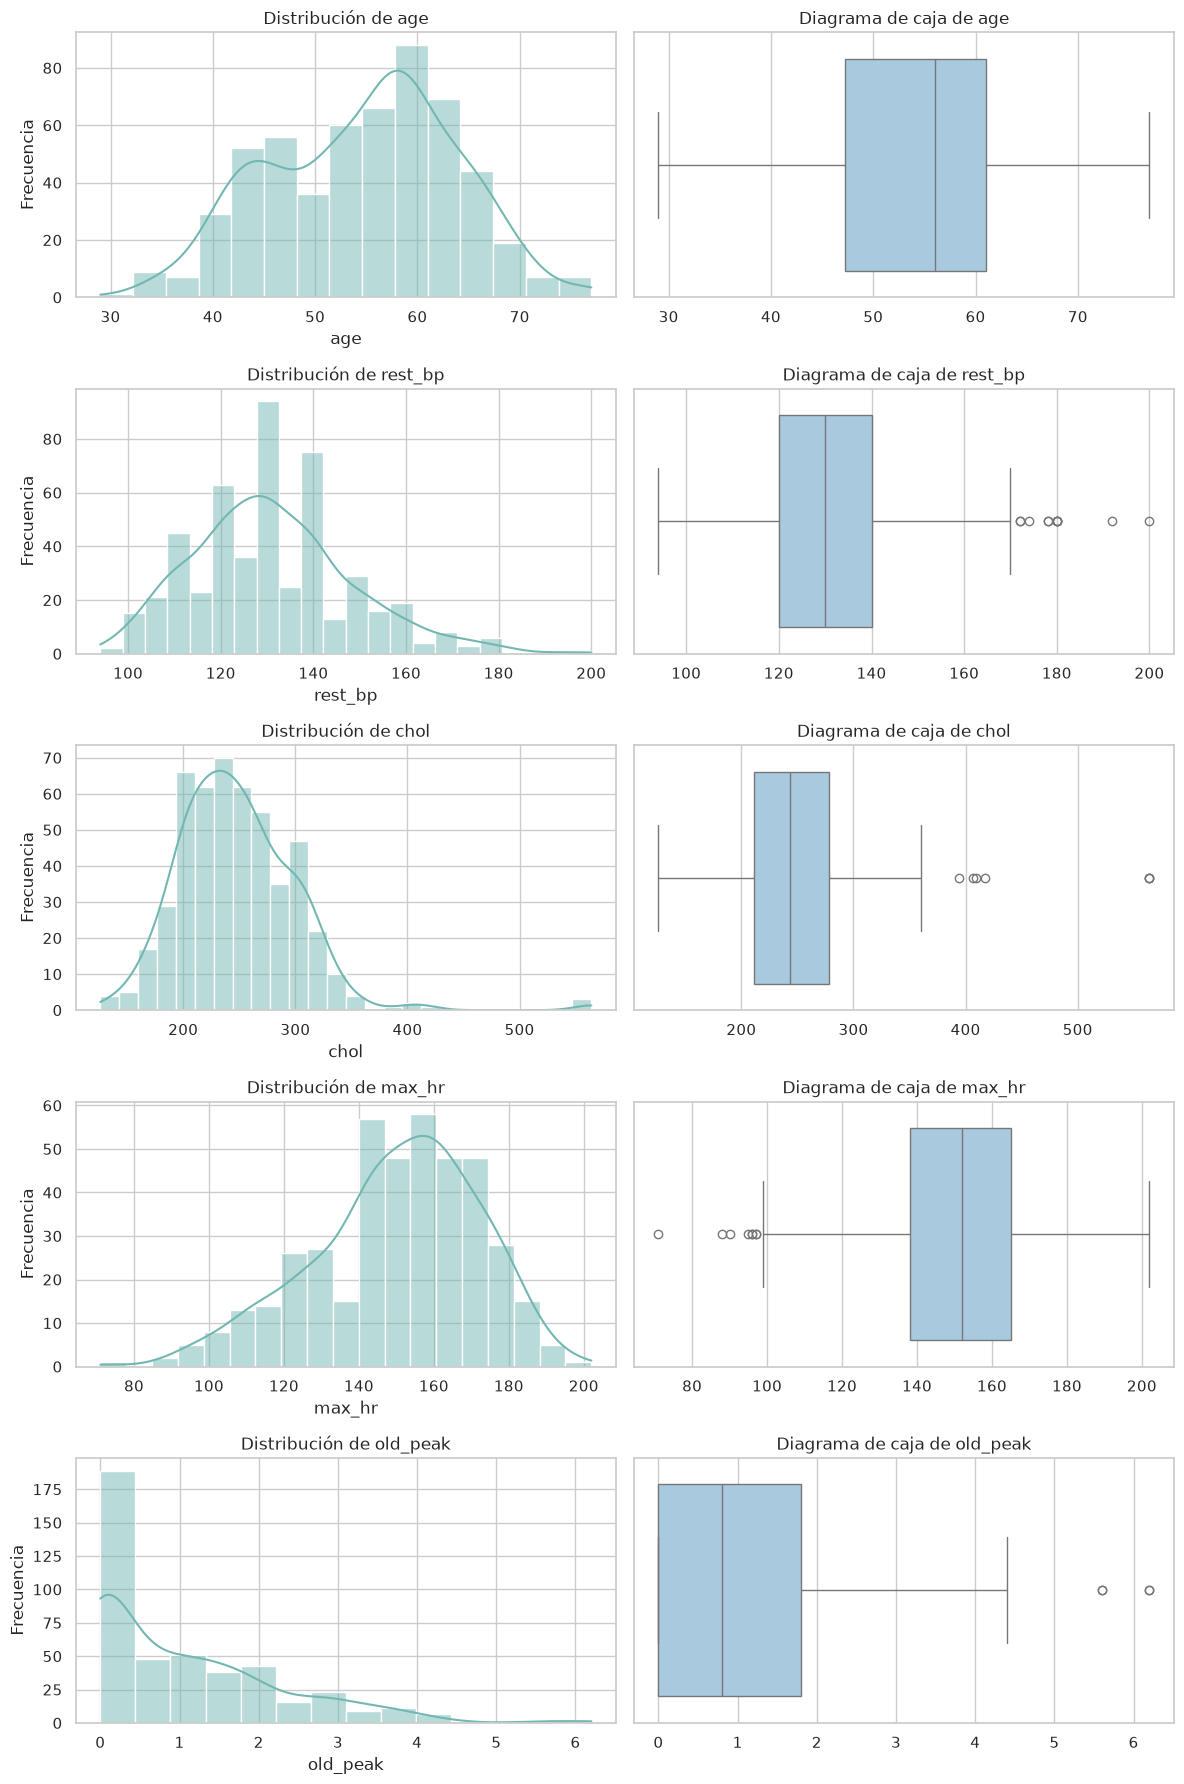

In [9]:
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(12, 18))

for row, column in enumerate(numeric_columns):
    values = analysis_df[column].dropna().astype(float)
    sns.histplot(values, kde=True, ax=axes[row, 0], color=COLOR_NEUTRAL)
    sns.boxplot(x=values, ax=axes[row, 1], color="#A0CBE8")
    axes[row, 0].set(title=f"Distribución de {column}", ylabel="Frecuencia")
    axes[row, 1].set(title=f"Diagrama de caja de {column}", xlabel="")

plt.tight_layout()
plt.show()

In [10]:
outlier_records = []

for column in numeric_columns:
    values = analysis_df[column].dropna().astype(float)
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outlier_mask = (values < lower_fence) | (values > upper_fence)
    outlier_records.append(
        {
            "variable": column,
            "observed_min": values.min(),
            "observed_max": values.max(),
            "lower_fence": lower_fence,
            "upper_fence": upper_fence,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": outlier_mask.mean() * 100,
        }
    )

outlier_summary = pd.DataFrame(outlier_records).set_index("variable")
outlier_summary.round(2)

,observed_min,observed_max,lower_fence,upper_fence,outlier_count,outlier_pct
variable,,,,,,
age,29.0,77.0,26.62,81.62,0,0.00
rest_bp,94.0,200.0,90.00,170.00,11,2.20
chol,126.0,564.0,110.50,378.50,7,1.41
max_hr,71.0,202.0,97.50,205.50,8,1.91
old_peak,0.0,6.2,-2.70,4.50,4,0.91


### Hallazgos numéricos

- `age` se concentra alrededor de 56 años y no presenta valores atípicos según la regla de Tukey.
- `chol` muestra asimetría positiva marcada (skewness 1,45) y siete observaciones atípicas; el máximo es 564 mg/dL.
- `old_peak` también es asimétrica a la derecha y presenta cuatro valores sobre la cerca superior de Tukey.
- `rest_bp` tiene once valores atípicos y `max_hr` ocho.
- Un valor atípico estadístico no es necesariamente un error clínico. En ausencia de una validación experta o de evidencia de captura incorrecta, no se elimina ni se recorta automáticamente.


## 📊 Análisis univariable: variables categóricas y discretas


In [11]:
categorical_columns = [
    "sex",
    "chest_pain",
    "fbs",
    "rest_ecg",
    "exang",
    "slope",
    "ca",
    "thal",
]

category_records = []
for column in categorical_columns:
    normalized = analysis_df[column].astype("string").fillna("<missing>")
    counts = normalized.value_counts(dropna=False)
    for category, count in counts.items():
        category_records.append(
            {
                "variable": column,
                "category": category,
                "count": count,
                "percentage": count / len(analysis_df) * 100,
            }
        )

category_summary = pd.DataFrame(category_records)
category_summary.round({"percentage": 2})

,variable,category,count,percentage
0,sex,Male,367,64.61
1,sex,Female,151,26.58
2,sex,<missing>,50,8.80
3,chest_pain,asymptomatic,231,40.67
4,chest_pain,nonanginal,148,26.06
5,chest_pain,nontypical,82,14.44
6,chest_pain,<missing>,72,12.68
7,chest_pain,typical,35,6.16
8,fbs,False,412,72.54
9,fbs,<missing>,83,14.61


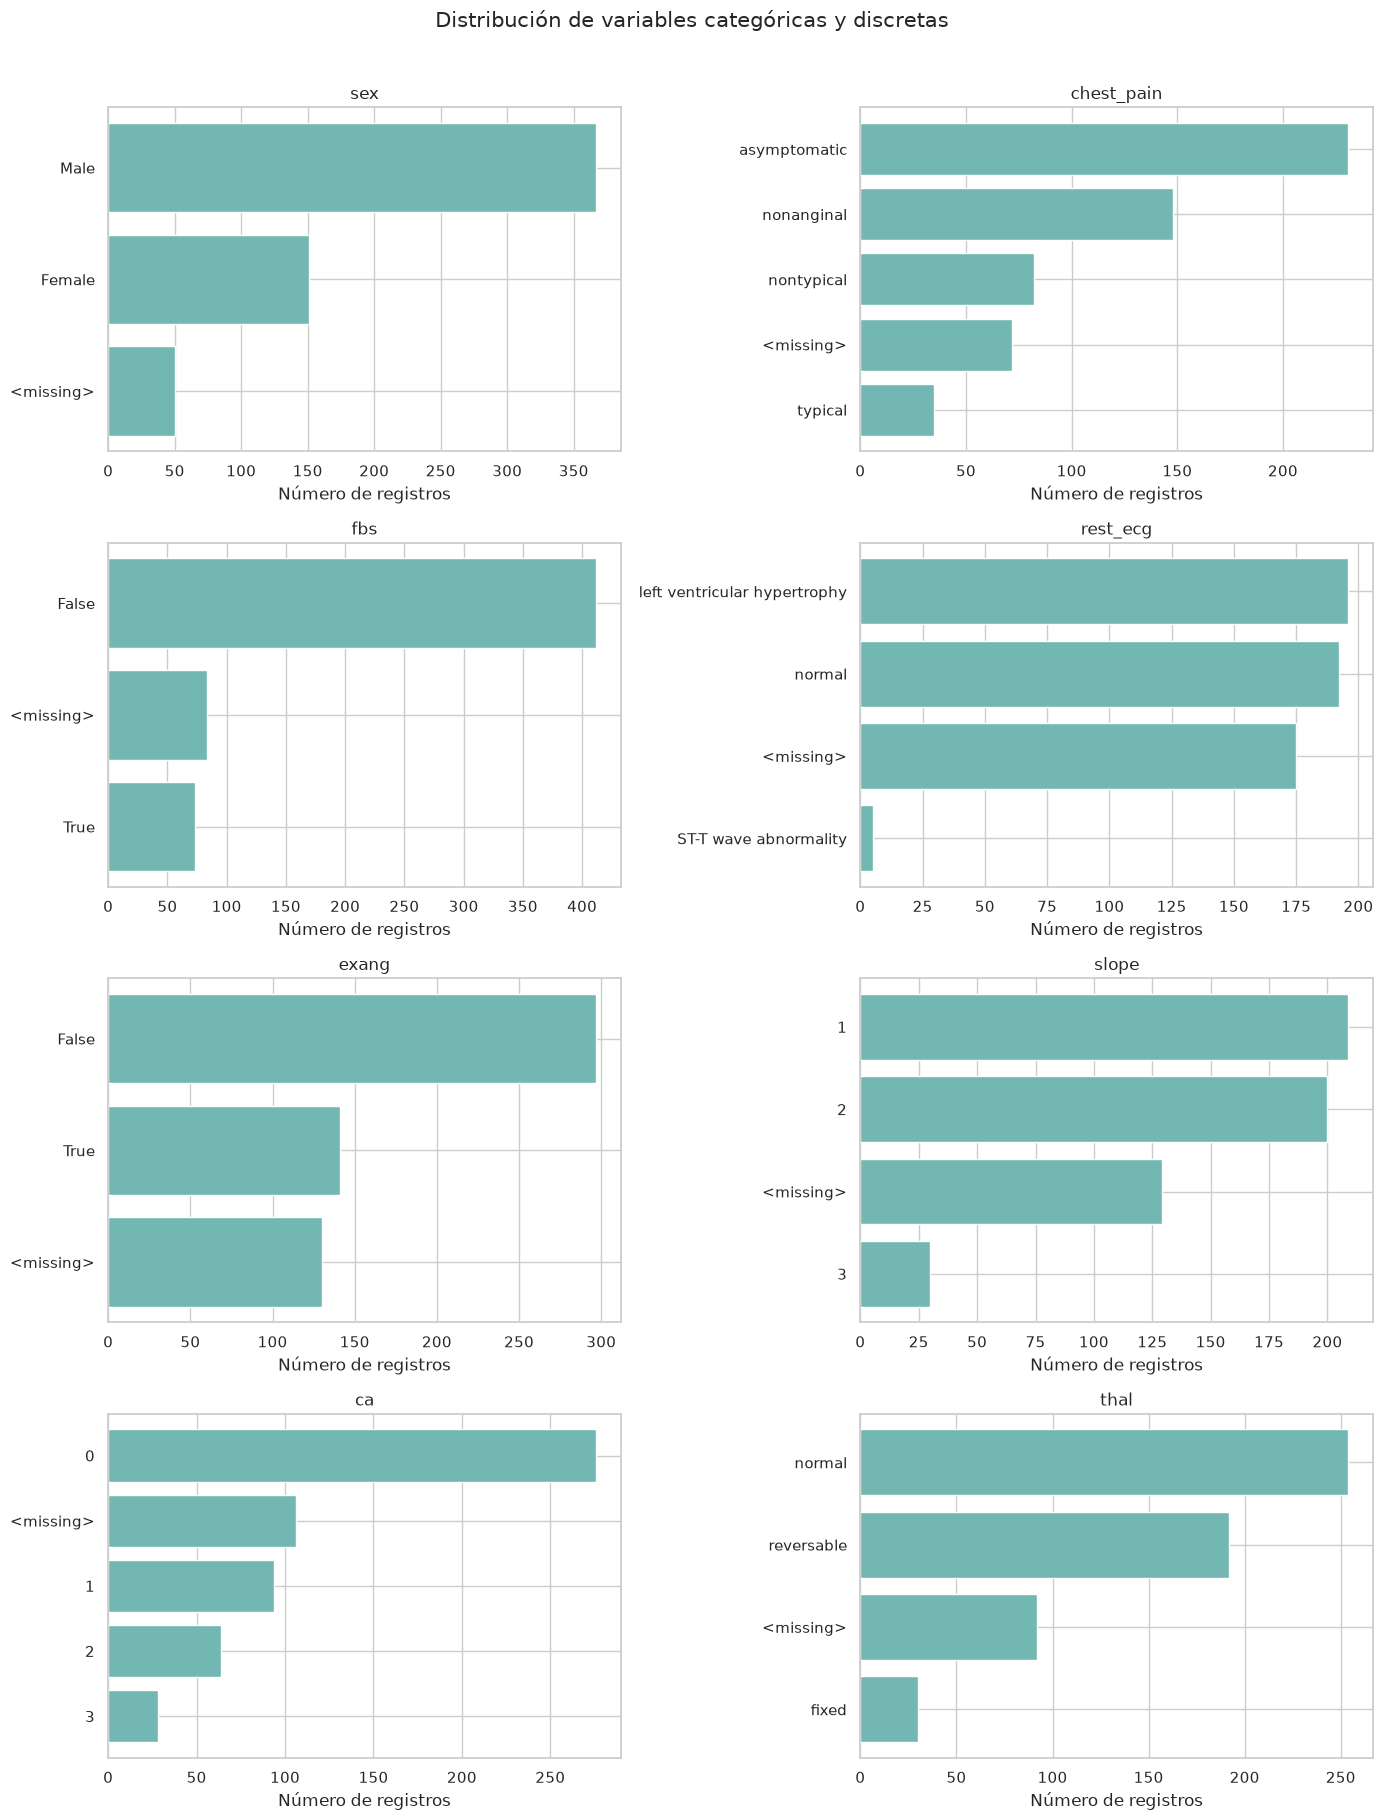

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for ax, column in zip(axes.flat, categorical_columns, strict=True):
    values = analysis_df[column].astype("string").fillna("<missing>")
    counts = values.value_counts().sort_values()
    ax.barh(counts.index, counts.values, color=COLOR_NEUTRAL)
    ax.set(title=column, xlabel="Número de registros", ylabel="")

plt.suptitle("Distribución de variables categóricas y discretas", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

Se observan categorías con pocos registros, especialmente `rest_ecg = ST-T wave abnormality` y `thal = fixed`. Estas categorías deben conservarse, pero sus porcentajes y asociaciones pueden ser inestables. En el modelamiento será importante usar particiones estratificadas y encoders capaces de manejar categorías poco frecuentes o desconocidas.


## 🎯 Variable objetivo: `disease`


In [13]:
target_labels = (
    analysis_df["disease"]
    .map({False: "Sin enfermedad", True: "Con enfermedad"})
    .astype("string")
    .fillna("Sin etiqueta")
)

target_summary = target_labels.value_counts().to_frame("count")
target_summary["percentage"] = (target_summary["count"] / len(analysis_df) * 100).round(2)

target_summary

,count,percentage
disease,,
Sin enfermedad,250,44.01
Con enfermedad,230,40.49
Sin etiqueta,88,15.49


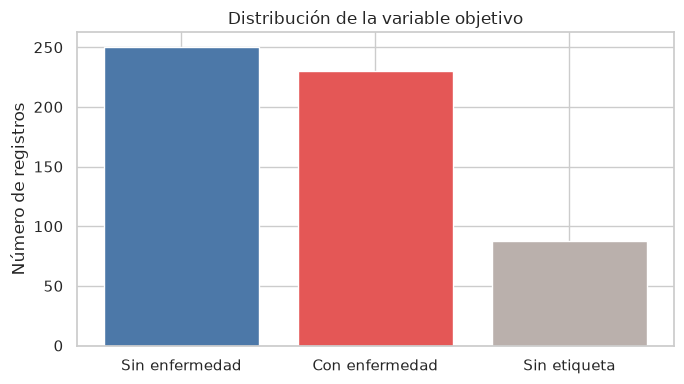

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = [
    COLOR_NEGATIVE
    if label == "Sin enfermedad"
    else COLOR_POSITIVE
    if label == "Con enfermedad"
    else "#BAB0AC"
    for label in target_summary.index
]
ax.bar(target_summary.index, target_summary["count"], color=colors)
ax.set(title="Distribución de la variable objetivo", ylabel="Número de registros", xlabel="")
plt.tight_layout()
plt.show()

Entre las 480 observaciones únicas con etiqueta disponible, 230 (47,92 %) tienen `disease = True` y 250 (52,08 %) `disease = False`. No existe un desbalance fuerte entre las clases válidas. Sin embargo, hay 88 observaciones únicas sin etiqueta; deberán excluirse del entrenamiento supervisado o recuperarse desde la fuente si fuera posible.


## 🔗 Análisis bivariable: variables numéricas frente al objetivo


In [15]:
def benjamini_hochberg(p_values: pd.Series) -> pd.Series:
    values = p_values.astype(float).to_numpy()
    order = np.argsort(values)
    ranked = values[order]
    adjusted = ranked * len(values) / np.arange(1, len(values) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.minimum(adjusted, 1.0)
    return pd.Series(result, index=p_values.index)


numeric_target_records = []
for column in numeric_columns:
    subset = analysis_df[[column, "disease"]].dropna()
    negative = subset.loc[~subset["disease"], column].astype(float)
    positive = subset.loc[subset["disease"], column].astype(float)
    u_statistic, p_value = stats.mannwhitneyu(
        positive,
        negative,
        alternative="two-sided",
    )
    rank_biserial = 2 * u_statistic / (len(positive) * len(negative)) - 1
    numeric_target_records.append(
        {
            "variable": column,
            "n": len(subset),
            "median_without_disease": negative.median(),
            "median_with_disease": positive.median(),
            "median_difference": positive.median() - negative.median(),
            "rank_biserial": rank_biserial,
            "p_value": p_value,
        }
    )

numeric_target_summary = pd.DataFrame(numeric_target_records).set_index("variable")
numeric_target_summary["q_value"] = benjamini_hochberg(numeric_target_summary["p_value"])
numeric_target_summary.round(4)

,n,median_without_disease,median_with_disease,median_difference,rank_biserial,p_value,q_value
variable,,,,,,,
age,463,53.0,58.00,5.00,0.2699,0.0000,0.0000
rest_bp,412,130.0,130.00,0.00,0.1666,0.0034,0.0042
chol,408,235.0,253.00,18.00,0.1340,0.0195,0.0195
max_hr,390,160.0,142.50,-17.50,-0.4675,0.0000,0.0000
old_peak,410,0.2,1.45,1.25,0.5200,0.0000,0.0000


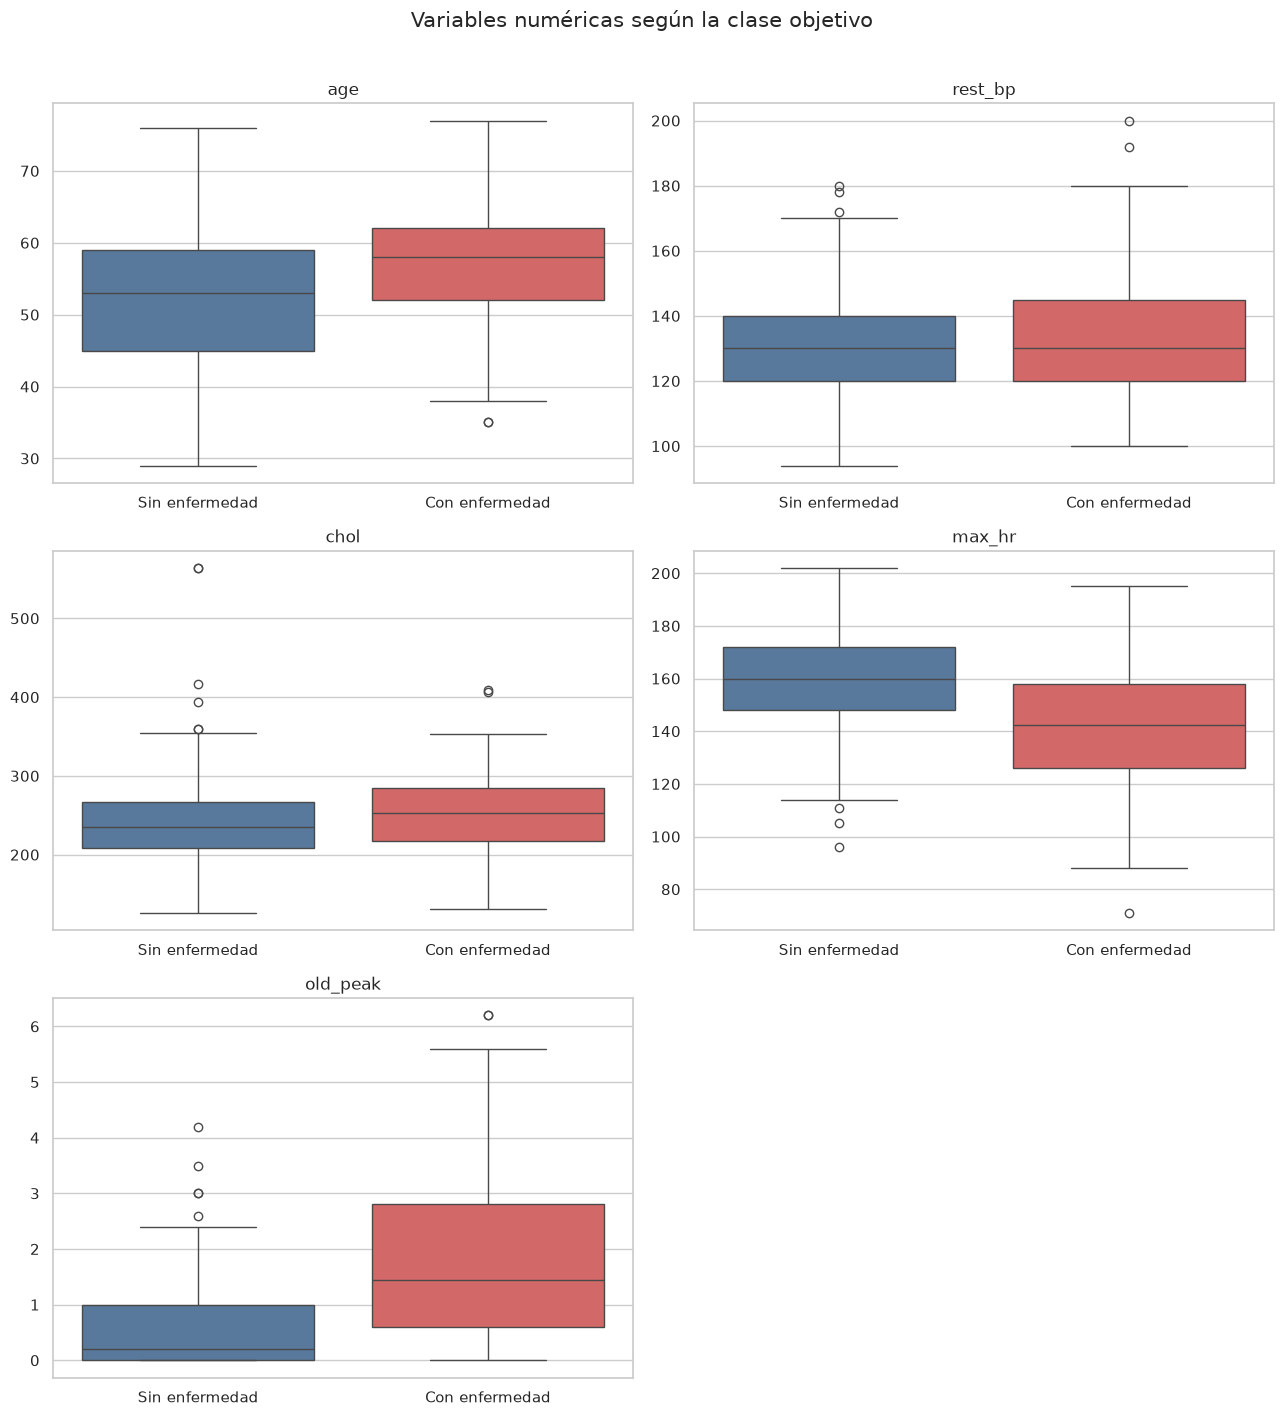

In [16]:
numeric_long = analysis_df.melt(
    id_vars="disease",
    value_vars=numeric_columns,
    var_name="variable",
    value_name="value",
).dropna()
numeric_long["disease_label"] = numeric_long["disease"].map(
    {False: "Sin enfermedad", True: "Con enfermedad"}
)

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
for ax, column in zip(axes.flat, numeric_columns, strict=False):
    subset = numeric_long.loc[numeric_long["variable"] == column]
    sns.boxplot(
        data=subset,
        x="disease_label",
        y="value",
        hue="disease_label",
        palette=[COLOR_NEGATIVE, COLOR_POSITIVE],
        legend=False,
        ax=ax,
    )
    ax.set(title=column, xlabel="", ylabel="")

axes[-1, -1].axis("off")
plt.suptitle("Variables numéricas según la clase objetivo", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

`old_peak` presenta la mayor separación numérica entre clases (correlación biserial por rangos 0,52; mediana 1,45 con enfermedad frente a 0,20 sin enfermedad). `max_hr` también diferencia los grupos en sentido inverso (-0,47; mediana 142,5 frente a 160 bpm). `age` muestra una relación moderada, mientras que `rest_bp` y `chol` presentan diferencias menores. Los valores q controlan comparaciones múltiples, pero no convierten estas asociaciones en evidencia causal.


## 🔗 Análisis bivariable: variables categóricas frente al objetivo


In [17]:
def cramers_v(table: pd.DataFrame) -> float:
    if table.shape[0] < MIN_LEVELS or table.shape[1] < MIN_LEVELS:
        return np.nan
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    return float(np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1))))


categorical_target_records = []
positive_rate_records = []

for column in categorical_columns:
    subset = analysis_df[[column, "disease"]].dropna()
    contingency = pd.crosstab(subset[column], subset["disease"])
    _, p_value, _, _ = stats.chi2_contingency(contingency, correction=False)
    rates = subset.groupby(column, observed=True)["disease"].agg(["mean", "count"])

    categorical_target_records.append(
        {
            "variable": column,
            "n": len(subset),
            "levels": subset[column].nunique(),
            "cramers_v": cramers_v(contingency),
            "p_value": p_value,
        }
    )

    for category, row in rates.iterrows():
        positive_rate_records.append(
            {
                "variable": column,
                "category": str(category),
                "positive_rate": row["mean"],
                "n": int(row["count"]),
            }
        )

categorical_target_summary = pd.DataFrame(categorical_target_records).set_index("variable")
categorical_target_summary["q_value"] = benjamini_hochberg(categorical_target_summary["p_value"])
categorical_target_summary.sort_values("cramers_v", ascending=False).round(4)

,n,levels,cramers_v,p_value,q_value
variable,,,,,
thal,448,3,0.5311,0.0000,0.0000
chest_pain,409,4,0.5277,0.0000,0.0000
ca,433,4,0.5032,0.0000,0.0000
exang,409,2,0.4570,0.0000,0.0000
slope,410,3,0.4171,0.0000,0.0000
sex,431,2,0.2604,0.0000,0.0000
rest_ecg,364,3,0.1785,0.0030,0.0035
fbs,398,2,0.0350,0.4845,0.4845


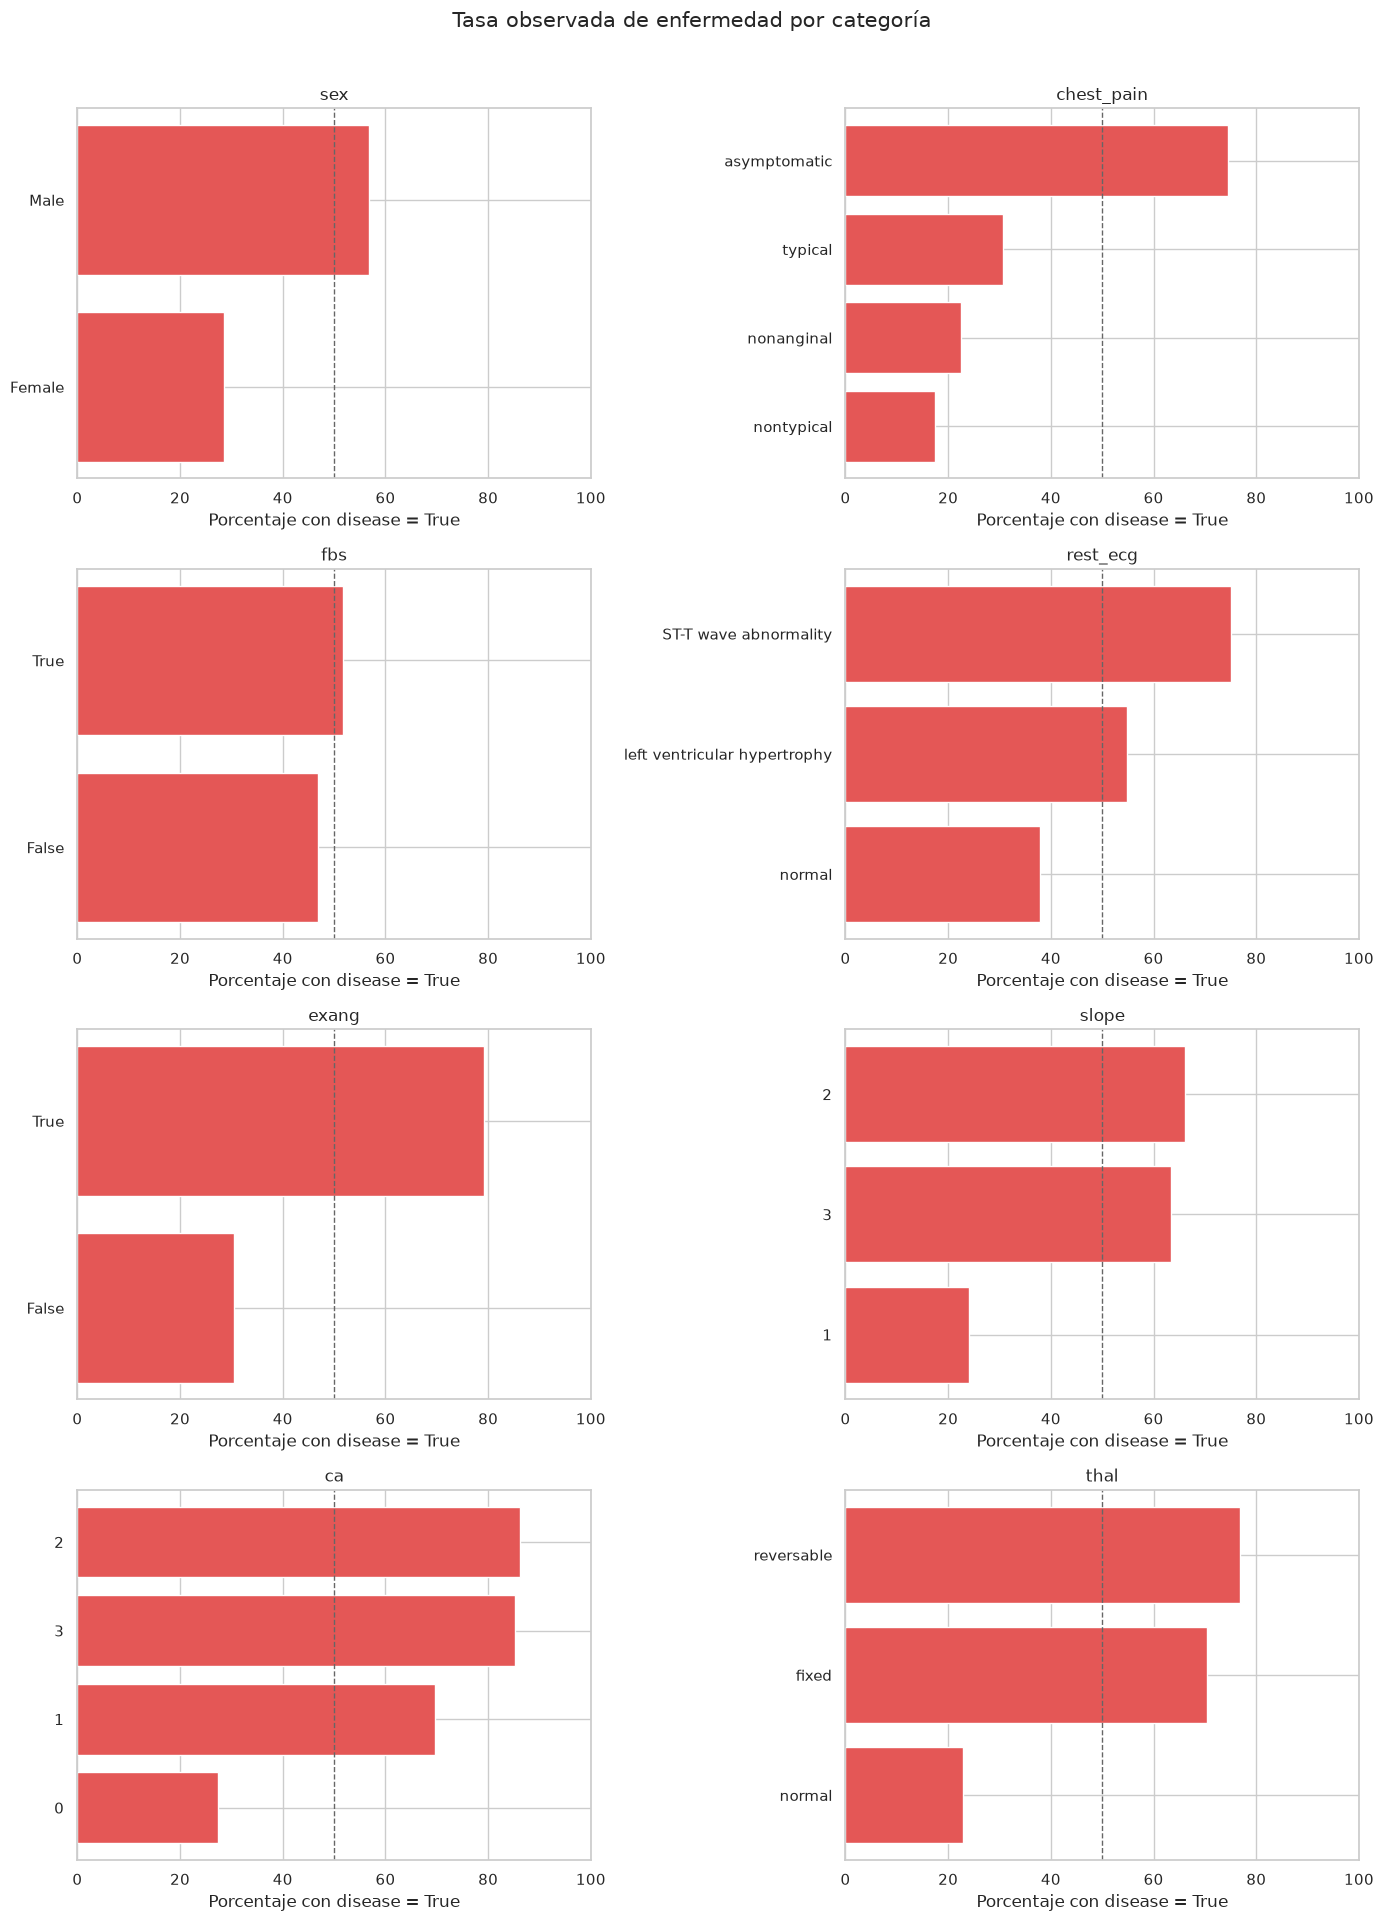

In [18]:
positive_rates = pd.DataFrame(positive_rate_records)
fig, axes = plt.subplots(4, 2, figsize=(14, 19))

for ax, column in zip(axes.flat, categorical_columns, strict=True):
    subset = positive_rates.loc[positive_rates["variable"] == column].sort_values("positive_rate")
    ax.barh(subset["category"], subset["positive_rate"] * 100, color=COLOR_POSITIVE)
    ax.axvline(50, color="#666666", linestyle="--", linewidth=1)
    ax.set(title=column, xlabel="Porcentaje con disease = True", ylabel="", xlim=(0, 100))

plt.suptitle("Tasa observada de enfermedad por categoría", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

Las asociaciones categóricas más fuertes con `disease` corresponden a `thal` (V de Cramér 0,53), `chest_pain` (0,53), `ca` (0,50), `exang` (0,46) y `slope` (0,42). `fbs` no muestra una asociación evidente en esta muestra (V 0,04; q ≈ 0,48). La categoría `ST-T wave abnormality` contiene solo cinco observaciones únicas con datos completos para el cruce, por lo que su tasa no debe generalizarse.


## 🧩 Análisis multivariable


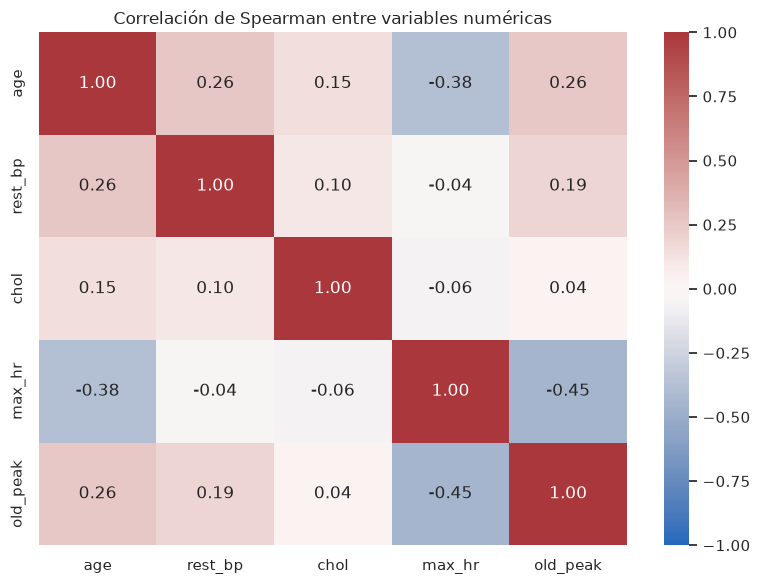

In [19]:
spearman_correlation = analysis_df[numeric_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlación de Spearman entre variables numéricas")
plt.tight_layout()
plt.show()

In [20]:
def correlation_ratio(categories: pd.Series, values: pd.Series) -> float:
    valid = categories.notna() & values.notna()
    cat = categories.loc[valid].astype("string")
    val = values.loc[valid].astype(float)
    if val.nunique() < MIN_LEVELS or cat.nunique() < MIN_LEVELS:
        return np.nan
    grand_mean = val.mean()
    numerator = sum(len(group) * (group.mean() - grand_mean) ** 2 for _, group in val.groupby(cat))
    denominator = ((val - grand_mean) ** 2).sum()
    return float(np.sqrt(numerator / denominator)) if denominator else np.nan


categorical_with_target = [*categorical_columns, "disease"]
all_variables = [*numeric_columns, *categorical_with_target]
association_matrix = pd.DataFrame(
    np.eye(len(all_variables)),
    index=all_variables,
    columns=all_variables,
)

for first, second in combinations(all_variables, 2):
    if first in numeric_columns and second in numeric_columns:
        association = abs(analysis_df[[first, second]].corr(method="spearman").iloc[0, 1])
    elif first in categorical_with_target and second in categorical_with_target:
        subset = analysis_df[[first, second]].dropna()
        association = cramers_v(pd.crosstab(subset[first], subset[second]))
    else:
        numeric = first if first in numeric_columns else second
        categorical = second if first in numeric_columns else first
        association = correlation_ratio(
            analysis_df[categorical],
            analysis_df[numeric],
        )
    association_matrix.loc[first, second] = association
    association_matrix.loc[second, first] = association

upper_triangle = np.triu(np.ones(association_matrix.shape), k=1).astype(bool)
top_associations = (
    association_matrix.where(upper_triangle)
    .stack()
    .sort_values(ascending=False)
    .head(12)
    .rename("association")
    .to_frame()
)
top_associations.round(3)

association
old_peak   slope           0.594
thal       disease         0.531
chest_pain disease         0.528
ca         disease         0.503
chest_pain exang           0.480
old_peak   disease         0.462
exang      disease         0.457
max_hr     old_peak        0.446
           slope           0.423
slope      disease         0.417
max_hr     disease         0.401
           exang           0.389

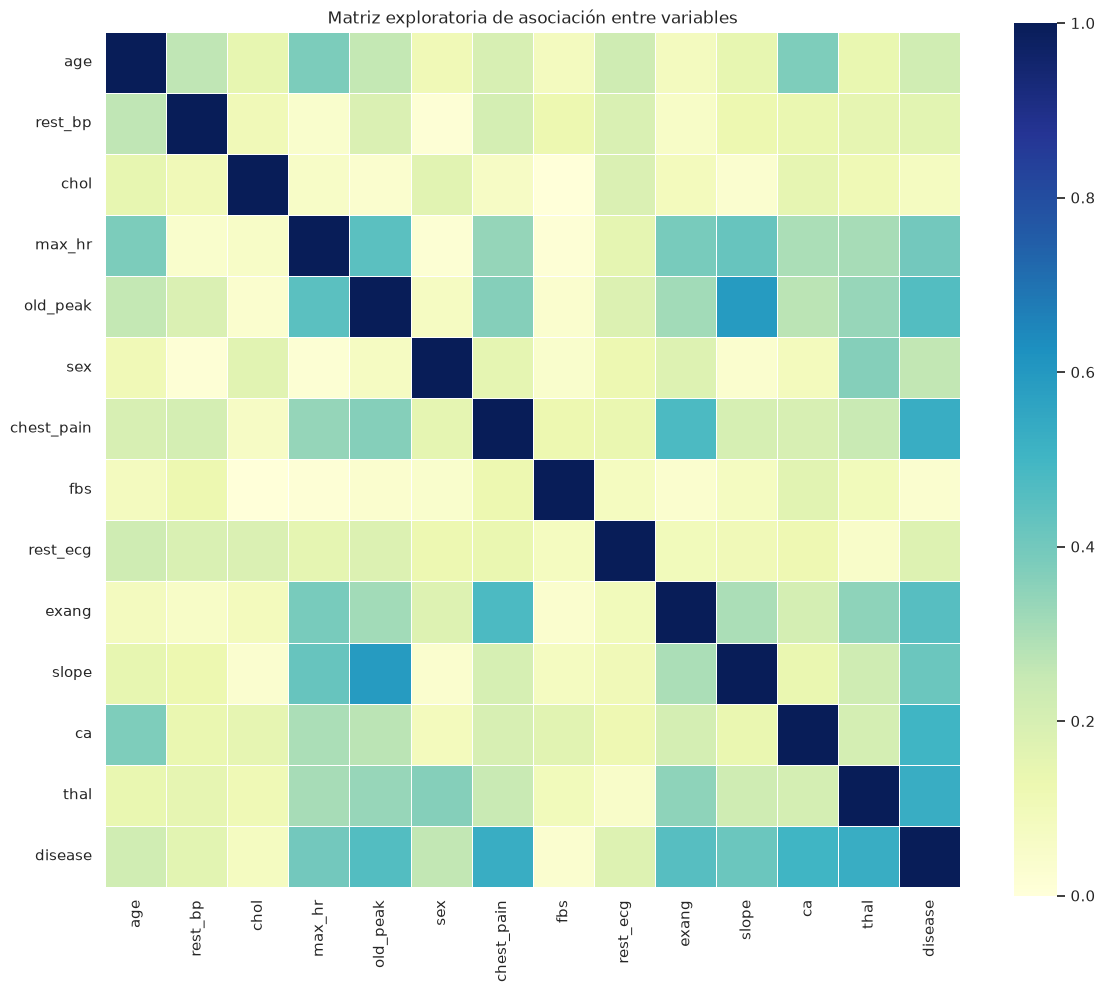

In [21]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    association_matrix,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Matriz exploratoria de asociación entre variables")
plt.tight_layout()
plt.show()

Las relaciones internas más visibles son `old_peak`–`slope` (η ≈ 0,59), `chest_pain`–`exang` (V ≈ 0,48), `max_hr`–`old_peak` (|ρ| ≈ 0,45) y `max_hr`–`slope` (η ≈ 0,42). Estos grupos contienen información relacionada y pueden generar redundancia en modelos lineales, aunque también pueden aportar interacciones útiles a modelos no lineales.

La matriz combina medidas distintas —|Spearman|, V de Cramér y razón de correlación η— en una escala de 0 a 1. Sirve para priorizar análisis, no para comparar causalidad ni dirección entre todos los pares.


## 🧠 Viabilidad de un modelo heurístico


In [22]:
heuristic_columns = [
    "ca",
    "thal",
    "exang",
    "old_peak",
    "chest_pain",
    "disease",
]
heuristic_df = analysis_df[heuristic_columns].dropna().copy()

heuristic_df["heuristic_score"] = (
    (heuristic_df["ca"] >= 1).astype(int)
    + heuristic_df["thal"].isin(["fixed", "reversable"]).astype(int)
    + heuristic_df["exang"].astype(int)
    + (heuristic_df["old_peak"] >= 1).astype(int)
    + heuristic_df["chest_pain"].eq("asymptomatic").astype(int)
)

heuristic_records = []
for threshold in range(1, 6):
    truth = heuristic_df["disease"].astype(bool)
    prediction = heuristic_df["heuristic_score"] >= threshold
    tp = int((truth & prediction).sum())
    tn = int((~truth & ~prediction).sum())
    fp = int((~truth & prediction).sum())
    fn = int((truth & ~prediction).sum())
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * precision * recall / (precision + recall)
    heuristic_records.append(
        {
            "threshold": threshold,
            "evaluated_rows": len(heuristic_df),
            "recall": recall,
            "specificity": specificity,
            "precision": precision,
            "f1": f1,
            "accuracy": (tp + tn) / len(heuristic_df),
            "false_negatives": fn,
            "false_positives": fp,
        }
    )

heuristic_results = pd.DataFrame(heuristic_records).set_index("threshold")
heuristic_results.round(3)

,evaluated_rows,recall,specificity,precision,f1,accuracy,false_negatives,false_positives
threshold,,,,,,,,
1,340,0.981,0.331,0.563,0.716,0.635,3,121
2,340,0.887,0.713,0.731,0.801,0.794,18,52
3,340,0.774,0.923,0.898,0.831,0.853,36,14
4,340,0.541,0.989,0.977,0.696,0.779,73,2
5,340,0.214,1.000,1.000,0.352,0.632,125,0


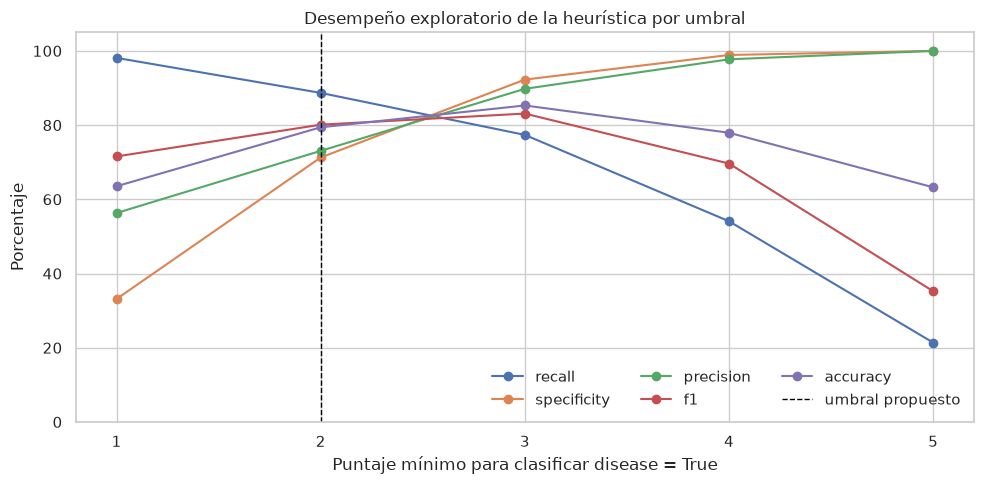

In [23]:
metric_columns = ["recall", "specificity", "precision", "f1", "accuracy"]
plot_metrics = heuristic_results[metric_columns].mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
for metric in metric_columns:
    ax.plot(plot_metrics.index, plot_metrics[metric], marker="o", label=metric)
ax.axvline(2, color="#000000", linestyle="--", linewidth=1, label="umbral propuesto")
ax.set(
    title="Desempeño exploratorio de la heurística por umbral",
    xlabel="Puntaje mínimo para clasificar disease = True",
    ylabel="Porcentaje",
    xticks=range(1, 6),
    ylim=(0, 105),
)
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

La heurística suma un punto por cada condición: `ca >= 1`, defecto en `thal`, `exang = True`, `old_peak >= 1` y dolor torácico asintomático. Con umbral **2**, en las 340 filas únicas y completas disponibles logra de manera exploratoria recall 88,7 %, especificidad 71,3 %, precisión 73,1 %, F1 80,1 % y accuracy 79,4 %.

**Recomendación:** sí es viable conservarla como baseline transparente, especialmente porque prioriza sensibilidad y produce pocos falsos negativos. No es un protocolo clínico validado: las reglas y el umbral se derivaron y evaluaron sobre la misma muestra completa, excluyen registros con nulos y pueden estar sobreajustados. En una etapa posterior deberá compararse con un `DummyClassifier` y evaluarse con particiones y validación cruzada sin duplicados entre train y test.


## ✅ Reglas propuestas para validación de datos


In [24]:
validation_rules = pd.DataFrame(
    [
        ("schema", "14 columnas esperadas, sin columnas desconocidas", "error"),
        ("sex", "Male o Female", "error"),
        ("chest_pain", "typical, asymptomatic, nonanginal o nontypical", "error"),
        ("fbs, exang, disease", "booleano o nulo", "error"),
        ("rest_ecg", "normal, ST-T wave abnormality o left ventricular hypertrophy", "error"),
        ("slope", "entero de 1 a 3 o nulo", "error"),
        ("ca", "entero de 0 a 3 o nulo", "error"),
        ("thal", "normal, fixed o reversable", "error"),
        ("numeric predictors", "valor numérico o nulo", "error"),
        (
            "numeric observed range",
            "alertar si se excede el rango observado de entrenamiento",
            "warning",
        ),
        ("disease for training", "no nulo en registros destinados a entrenamiento", "error"),
        ("exact duplicates", "cero duplicados después del feature pipeline", "error"),
        ("missingness", "monitorear por variable y comparar con la línea base", "warning"),
    ],
    columns=["field", "proposed_rule", "action"],
)

validation_rules

,field,proposed_rule,action
0,schema,"14 columnas esperadas, sin columnas desconocidas",error
1,sex,Male o Female,error
2,chest_pain,"typical, asymptomatic, nonanginal o nontypical",error
3,"fbs, exang, disease",booleano o nulo,error
4,rest_ecg,"normal, ST-T wave abnormality o left ventricul...",error
5,slope,entero de 1 a 3 o nulo,error
6,ca,entero de 0 a 3 o nulo,error
7,thal,"normal, fixed o reversable",error
8,numeric predictors,valor numérico o nulo,error
9,numeric observed range,alertar si se excede el rango observado de ent...,warning


Los rangos observados pueden utilizarse inicialmente como alertas de *data drift*, no como límites clínicos definitivos. Los umbrales fisiológicos de rechazo deben ser definidos o aprobados por expertos y documentados con unidades. La forma `reversable` se mantiene por compatibilidad con el archivo entregado; una corrección a `reversible` debe realizarse mediante un mapeo explícito y auditable.


## 🛠 Preparación e ingeniería de atributos recomendadas

1. **Duplicados:** investigar su procedencia y eliminar duplicados exactos antes de dividir los datos, evitando que una misma observación aparezca en train y test.
2. **Target faltante:** excluir del entrenamiento supervisado las filas sin `disease`, conservándolas separadamente si pudieran etiquetarse después.
3. **Imputación:** mediana para variables numéricas y categoría más frecuente o categoría explícita de faltante para categóricas; todos los imputadores deben ajustarse únicamente con train.
4. **Codificación:** One-Hot Encoding para `sex`, `chest_pain`, `rest_ecg` y `thal`; mantener booleanas como 0/1. Evaluar `slope` y `ca` como ordinal/discreta frente a su codificación categórica.
5. **Escalado:** estandarizar variables numéricas para modelos lineales o basados en distancias. Los modelos de árboles no lo requieren.
6. **Valores atípicos:** conservar inicialmente y comparar estrategias robustas. No eliminarlos por la regla IQR sin justificación clínica.
7. **Partición:** usar train/test estratificado por `disease` y mantener la eliminación de duplicados antes de la partición.
8. **Interacciones:** evaluar combinaciones coherentes con los hallazgos, como `old_peak`–`slope`, `chest_pain`–`exang` y `max_hr`–`old_peak`, evitando crear reglas clínicas no validadas.


## ➕ Datos adicionales potencialmente útiles

- Identificador anónimo de paciente o de encuentro para distinguir repeticiones reales de duplicados.
- Fecha, centro y método de medición para evaluar cambios temporales y diferencias de procedencia.
- Antecedentes familiares, tabaquismo, actividad física, índice de masa corporal y medicación.
- Diagnósticos confirmatorios, desenlaces posteriores y momento de la confirmación de `disease`.
- Información sobre el mecanismo que generó los valores faltantes y sobre la ampliación del dataset.

Estas variables permitirían mejorar la validación, estudiar sesgos, evitar fuga entre encuentros del mismo paciente y evaluar la utilidad clínica del modelo.


## 📌 Conclusiones

- El dataset completo contiene 3.030 filas, pero 2.462 son duplicados exactos; la vista analítica queda en 568 filas únicas.
- La deduplicación revela mayor faltancia que la sugerida por el dataset completo: `rest_ecg`, `max_hr`, `exang`, `old_peak` y `slope` requieren especial atención.
- La variable objetivo está razonablemente balanceada entre las observaciones únicas etiquetadas.
- `old_peak` y `max_hr` muestran las mayores separaciones numéricas frente al objetivo.
- `thal`, `chest_pain`, `ca`, `exang` y `slope` presentan las asociaciones categóricas más fuertes con `disease`.
- Los valores atípicos detectados son pocos y plausibles; no deben eliminarse automáticamente.
- Es necesario construir el pipeline de Feature Engineering antes del modelamiento para resolver duplicados, target faltante, imputación, codificación y escalado sin fuga de información.
- La heurística de cinco condiciones es viable como baseline interpretable, pero requiere validación separada y no debe utilizarse como protocolo clínico.


## 📖 Referencias

- Archivo informativo suministrado con el proyecto: `data/01_raw/datos_corazon_Info.txt`.
- [Evaluación del curso: Ciencia de Datos en Producción](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/intro/evaluacion/).
- [Ejemplo del profesor: Análisis del proyecto Titanic](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/).
- [SciPy: pruebas estadísticas](https://docs.scipy.org/doc/scipy/reference/stats.html).
- [Seaborn: visualización estadística](https://seaborn.pydata.org/).

**Nota ética:** los resultados son exploratorios y educativos. El dataset modificado no documenta representatividad poblacional, proceso de muestreo ni validación clínica; por ello no debe emplearse para decisiones asistenciales reales.
